In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
data = pd.read_csv("sales_train_validation .csv/sales_train_validation.csv")
print(data.shape)
data.head()

(30490, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [4]:
# Extract daily sales column
d_cols = [col for col in data.columns if col.startswith('d_')]
print(len(d_cols))

1913


In [5]:
#Create total daily sales
total_sales = data[d_cols].sum(axis=0)

Total sales per day across all items:

In [6]:
# Converting into time series data frame
df = pd.DataFrame({
    "Day": range(1, len(total_sales)+1),
    "Sales": total_sales.values
})

df.set_index("Day", inplace=True)
print(df.shape)
df.head()

(1913, 1)


,Sales
Day,
1,32631
2,31749
3,23783
4,25412
5,19146


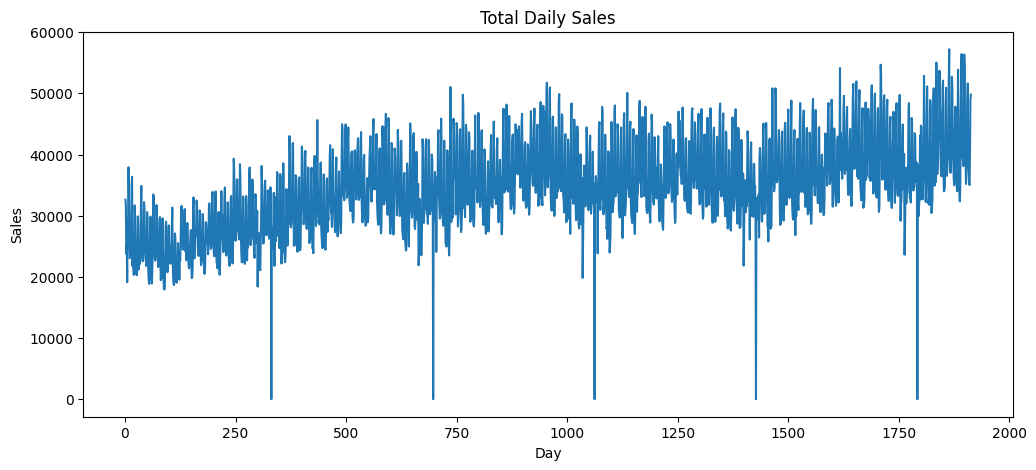

In [7]:
# Visualization in time series
plt.figure(figsize=(12,5))
plt.plot(df['Sales'])
plt.title("Total Daily Sales")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

In [8]:
# Stationarity test- Adfuller Test
result = adfuller(df['Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.5653733253318474
p-value: 0.500960436179774


Sales data usually gives p > 0.05, meaning we need differencing

In [9]:
# Differencing
df['Differenced'] = df['Sales'].diff()

df = df.dropna()

Differenced = Current Sales − Previous Sales

<Figure size 1000x500 with 0 Axes>

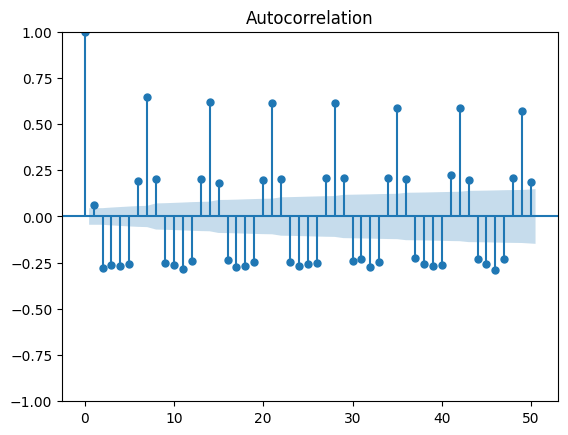

In [10]:
# Plot ACF
plt.figure(figsize=(10,5))
plot_acf(df['Differenced'], lags=50)
plt.show()

ACF shows autocorrelation with previous lags.Used to estimate MA parameter (q).

<Figure size 1000x500 with 0 Axes>

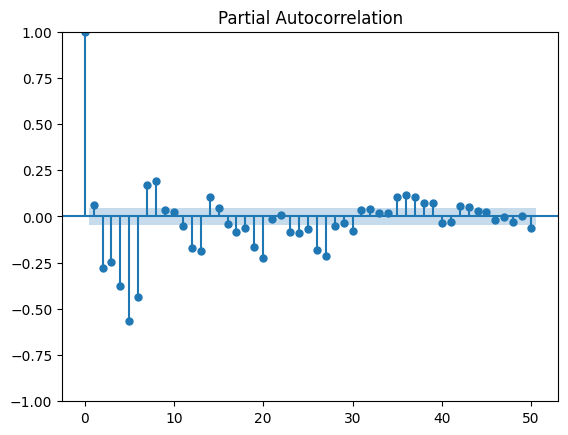

In [11]:
#plot PACF
plt.figure(figsize=(10,5))
plot_pacf(df['Differenced'], lags=50)
plt.show()

PACF shows direct correlation with lags.Used to estimate AR parameter (p).

In [12]:
# train ARIMA Model
model = ARIMA(df['Sales'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1912
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -19055.395
Date:                Mon, 09 Mar 2026   AIC                          38116.790
Time:                        11:13:06   BIC                          38133.456
Sample:                             0   HQIC                         38122.923
                               - 1912                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4980      0.018     27.645      0.000       0.463       0.533
ma.L1         -0.9821      0.005   -189.328      0.000      -0.992      -0.972
sigma2       2.68e+07   1.04e-10   2.57e+17      0.0

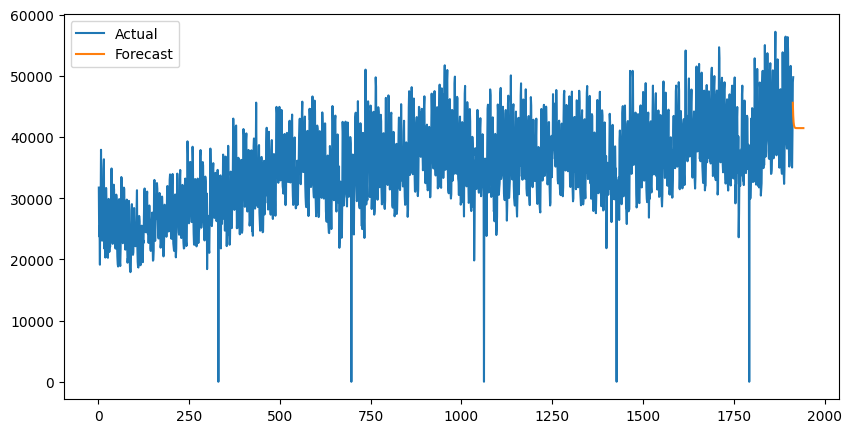

In [13]:
# Forecast future
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(df['Sales'], label="Actual")
plt.plot(range(len(df), len(df)+30), forecast, label="Forecast")
plt.legend()
plt.show()

In [14]:
train = df['Sales'][:1800]
test = df['Sales'][1800:]

In [23]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

In [16]:
forecast = model_fit.forecast(steps=len(test))
forecast

1802    40958.484000
1803    39284.420223
1804    38455.653028
1805    38045.360975
1806    37842.240521
            ...     
1909    37643.091995
1910    37643.091995
1911    37643.091995
1912    37643.091995
1913    37643.091995
Name: predicted_mean, Length: 112, dtype: float64

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 7813.322756546443


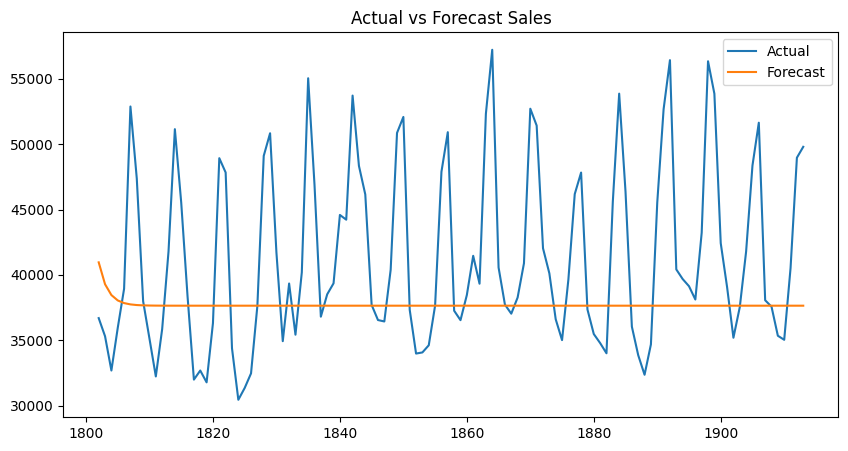

In [18]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("Actual vs Forecast Sales")
plt.show()

In [19]:
actual = df['Sales'][-112:]
predicted = forecast

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("RMSE:", rmse)

RMSE: 7813.322756546443


In [20]:
df['Sales'].describe()

count     1912.000000
mean     34342.457113
std       7347.722704
min         11.000000
25%      29651.500000
50%      33732.000000
75%      38693.500000
max      57218.000000
Name: Sales, dtype: float64

In [21]:
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
print("MAPE:", mape)

MAPE: 12.735164358519487


predictions differ from the actual sales by about 12.7%.